## 0. Importing libraries

In [1]:
import nltk
import math
import string
from collections import Counter, defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

## 1. DOWNLOAD NLTK RESOURCES

In [10]:
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import gutenberg
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## 2. LOAD DATASET

In [49]:
# We use 20 documents from Gutenberg corpus
doc_ids = gutenberg.fileids()[:20]
raw_documents = {doc_id: gutenberg.raw(doc_id) for doc_id in doc_ids}

print("Selected documents:")
for d in doc_ids:
    print("-", d)

Selected documents:
- austen-emma.txt
- austen-persuasion.txt
- austen-sense.txt
- bible-kjv.txt
- blake-poems.txt
- bryant-stories.txt
- burgess-busterbrown.txt
- carroll-alice.txt
- chesterton-ball.txt
- chesterton-brown.txt
- chesterton-thursday.txt
- edgeworth-parents.txt
- melville-moby_dick.txt
- milton-paradise.txt
- shakespeare-caesar.txt
- shakespeare-hamlet.txt
- shakespeare-macbeth.txt
- whitman-leaves.txt


## 3. CUSTOM STOPWORDS

In [30]:
custom_stopwords = {
    "the", "and", "of", "to", "a",
    "in", "is", "it", "that", "was",
    "he", "she", "they", "for", "on",
    "with", "as", "his", "her", "at"
}

## 4. PREPROCESSING FUNCTION

In [31]:
def preprocess(text):
    # lowercasing
    text = text.lower()

    # punctuation removal
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenization
    tokens = word_tokenize(text)

    # keep alphabetic tokens only
    tokens = [t for t in tokens if t.isalpha()]

    # stopword removal
    tokens = [t for t in tokens if t not in custom_stopwords]

    return tokens

# preprocess all documents
processed_docs = {doc_id: preprocess(text) for doc_id, text in raw_documents.items()}


## 5. SHOW PREPROCESSING OUTPUT

In [32]:
print("\n--- PREPROCESSING OUTPUT EXAMPLE ---")
for doc_id in doc_ids[:3]:
    print(f"\nDocument: {doc_id}")
    print(processed_docs[doc_id][:40])


--- PREPROCESSING OUTPUT EXAMPLE ---

Document: austen-emma.txt
['emma', 'by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse', 'handsome', 'clever', 'rich', 'comfortable', 'home', 'happy', 'disposition', 'seemed', 'unite', 'some', 'best', 'blessings', 'existence', 'had', 'lived', 'nearly', 'twentyone', 'years', 'world', 'very', 'little', 'distress', 'or', 'vex', 'youngest', 'two', 'daughters', 'most', 'affectionate', 'indulgent']

Document: austen-persuasion.txt
['persuasion', 'by', 'jane', 'austen', 'chapter', 'sir', 'walter', 'elliot', 'kellynch', 'hall', 'somersetshire', 'man', 'who', 'own', 'amusement', 'never', 'took', 'up', 'any', 'book', 'but', 'baronetage', 'there', 'found', 'occupation', 'an', 'idle', 'hour', 'consolation', 'distressed', 'one', 'there', 'faculties', 'were', 'roused', 'into', 'admiration', 'respect', 'by', 'contemplating']

Document: austen-sense.txt
['sense', 'sensibility', 'by', 'jane', 'austen', 'chapter', 'family', 'dashwood', 'had', 

## 6. TERM FREQUENCY (TF)

In [51]:
tf = {}

for doc_id, tokens in processed_docs.items():
    counts = Counter(tokens)
    total_terms = len(tokens)
    tf[doc_id] = {term: count / total_terms for term, count in counts.items()}

## 7. DOCUMENT FREQUENCY (DF)

In [53]:
df = defaultdict(int)

for doc_id, tokens in processed_docs.items():
    unique_terms = set(tokens)
    for term in unique_terms:
        df[term] += 1

N = len(processed_docs)

## 8. INVERSE DOCUMENT FREQUENCY (IDF)

In [35]:
idf = {term: math.log(N / df_val) for term, df_val in df.items()}

## 9. TF-IDF

In [55]:
tf_idf = {}

for doc_id, term_freqs in tf.items():
    tf_idf[doc_id] = {
        term: term_freqs[term] * idf[term]
        for term in term_freqs
    }

## 10. QUERY SCORING

In [59]:
query = "Love Marriage"
query_terms = preprocess(query)

scores = {}
for doc_id in doc_ids:
    score = sum(tf_idf[doc_id].get(term, 0.0) for term in query_terms)
    scores[doc_id] = score

ranked_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)

print("\n--- QUERY TERMS ---")
print(query_terms)

print("\n--- DOCUMENTS SORTED BY QUERY SCORE ---")
for doc_id, score in ranked_docs:
    print(f"{doc_id:30s} -> {score:.6f}")


--- QUERY TERMS ---
['love', 'marriage']

--- DOCUMENTS SORTED BY QUERY SCORE ---
blake-poems.txt                -> 0.001059
whitman-leaves.txt             -> 0.000552
austen-sense.txt               -> 0.000432
austen-persuasion.txt          -> 0.000360
austen-emma.txt                -> 0.000334
milton-paradise.txt            -> 0.000314
shakespeare-hamlet.txt         -> 0.000130
edgeworth-parents.txt          -> 0.000127
bible-kjv.txt                  -> 0.000126
bryant-stories.txt             -> 0.000094
chesterton-thursday.txt        -> 0.000085
chesterton-ball.txt            -> 0.000081
melville-moby_dick.txt         -> 0.000036
chesterton-brown.txt           -> 0.000033
shakespeare-caesar.txt         -> 0.000031
carroll-alice.txt              -> 0.000030
burgess-busterbrown.txt        -> 0.000017
shakespeare-macbeth.txt        -> 0.000000


## 11. BUILD FULL VOCABULARY

In [60]:
vocab = sorted(df.keys())
term_index = {term: i for i, term in enumerate(vocab)}

## 12. VECTORIZE DOCUMENTS

In [61]:
def vectorize(doc_weights, vocab):
    return np.array([doc_weights.get(term, 0.0) for term in vocab])

doc_vectors = {doc_id: vectorize(tf_idf[doc_id], vocab) for doc_id in doc_ids}


## 13. COSINE SIMILARITY

In [62]:
def cosine_similarity(vec1, vec2):
    dot = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)

# Pairwise similarities
pair_sims = []
for d1, d2 in combinations(doc_ids, 2):
    sim = cosine_similarity(doc_vectors[d1], doc_vectors[d2])
    pair_sims.append((d1, d2, sim))

pair_sims.sort(key=lambda x: x[2], reverse=True)

print("\n--- TOP 10 MOST SIMILAR DOCUMENT PAIRS ---")
for d1, d2, sim in pair_sims[:10]:
    print(f"{d1:30s} <-> {d2:30s} : {sim:.6f}")

most_similar_pair = pair_sims[0]
print("\nMost similar documents:")
print(most_similar_pair)


--- TOP 10 MOST SIMILAR DOCUMENT PAIRS ---
shakespeare-hamlet.txt         <-> shakespeare-macbeth.txt        : 0.309001
milton-paradise.txt            <-> whitman-leaves.txt             : 0.266871
shakespeare-caesar.txt         <-> shakespeare-hamlet.txt         : 0.253114
shakespeare-caesar.txt         <-> shakespeare-macbeth.txt        : 0.225022
blake-poems.txt                <-> milton-paradise.txt            : 0.224552
bible-kjv.txt                  <-> milton-paradise.txt            : 0.208225
blake-poems.txt                <-> whitman-leaves.txt             : 0.159303
melville-moby_dick.txt         <-> whitman-leaves.txt             : 0.126912
austen-persuasion.txt          <-> edgeworth-parents.txt          : 0.118910
austen-sense.txt               <-> edgeworth-parents.txt          : 0.113833

Most similar documents:
('shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', np.float64(0.30900144894804393))


## 14. SIMILARITY MATRIX

In [63]:
similarity_matrix = np.zeros((len(doc_ids), len(doc_ids)))

for i, d1 in enumerate(doc_ids):
    for j, d2 in enumerate(doc_ids):
        similarity_matrix[i, j] = cosine_similarity(doc_vectors[d1], doc_vectors[d2])


## 15. HEATMAP VISUALIZATION

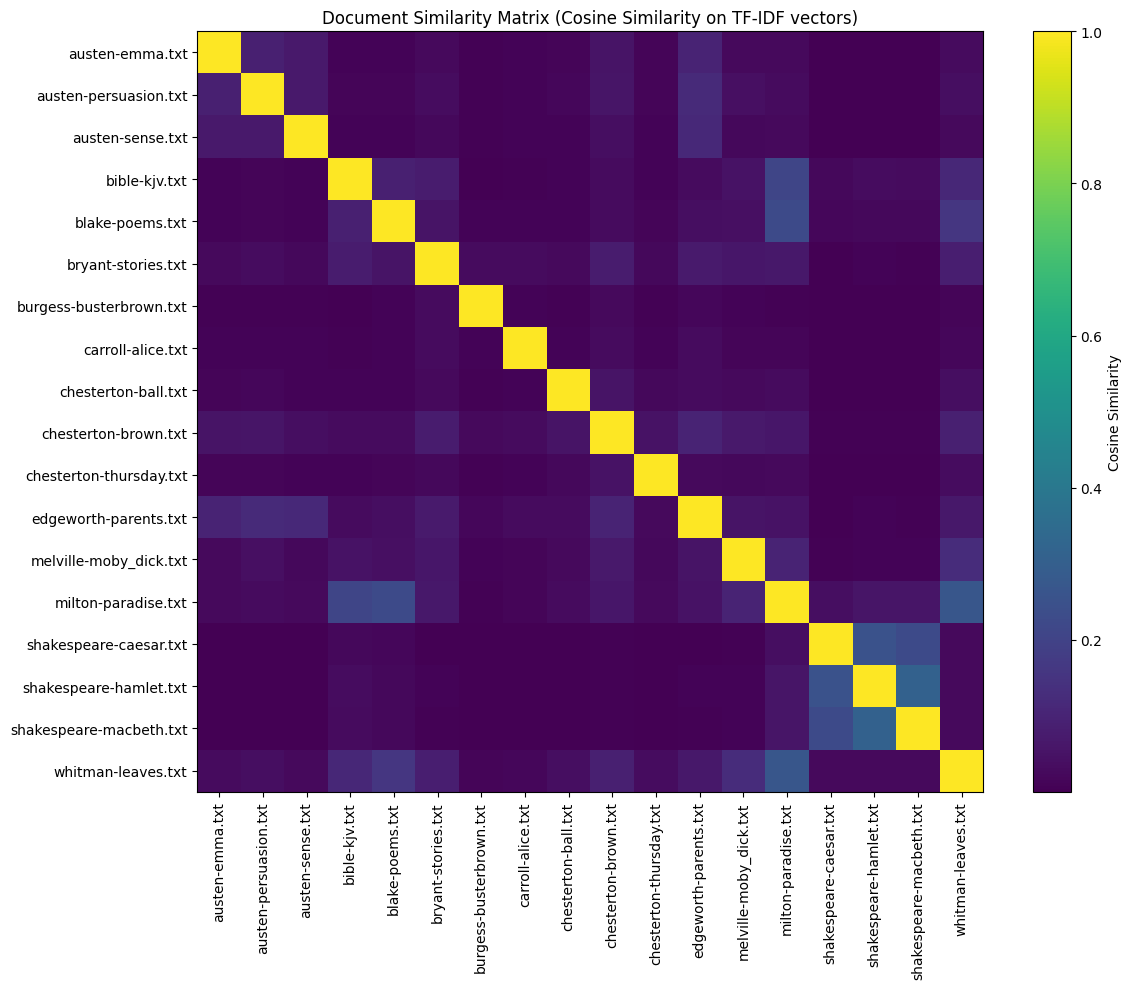

In [64]:
plt.figure(figsize=(12, 10))
plt.imshow(similarity_matrix, interpolation='nearest', aspect='auto')
plt.colorbar(label="Cosine Similarity")
plt.xticks(range(len(doc_ids)), doc_ids, rotation=90)
plt.yticks(range(len(doc_ids)), doc_ids)
plt.title("Document Similarity Matrix (Cosine Similarity on TF-IDF vectors)")
plt.tight_layout()
plt.show()

## 16. BAR CHART OF TF-IDF WEIGHTS


Showing TF-IDF bar charts for 3 example documents...


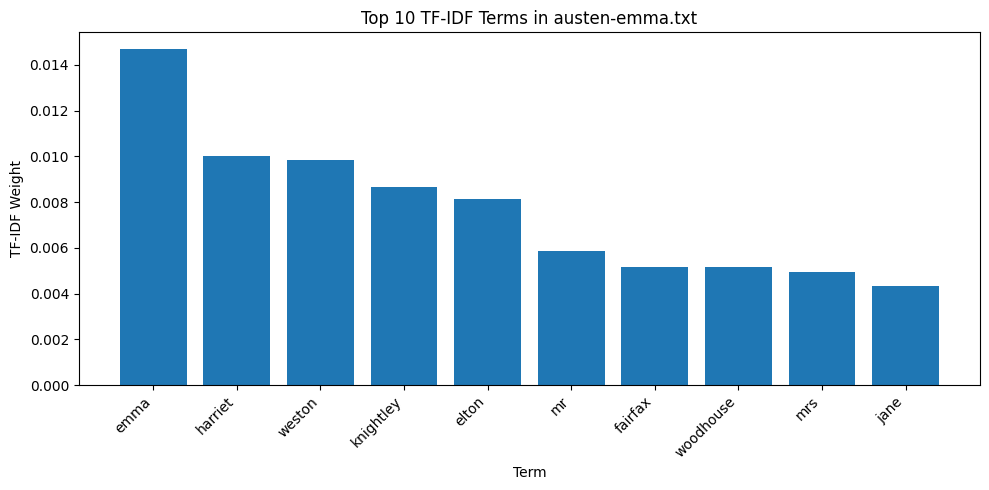

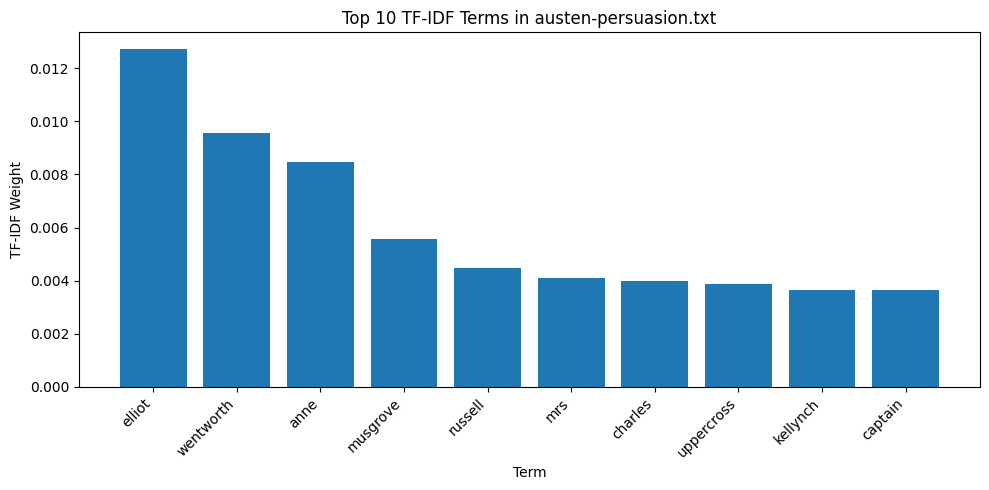

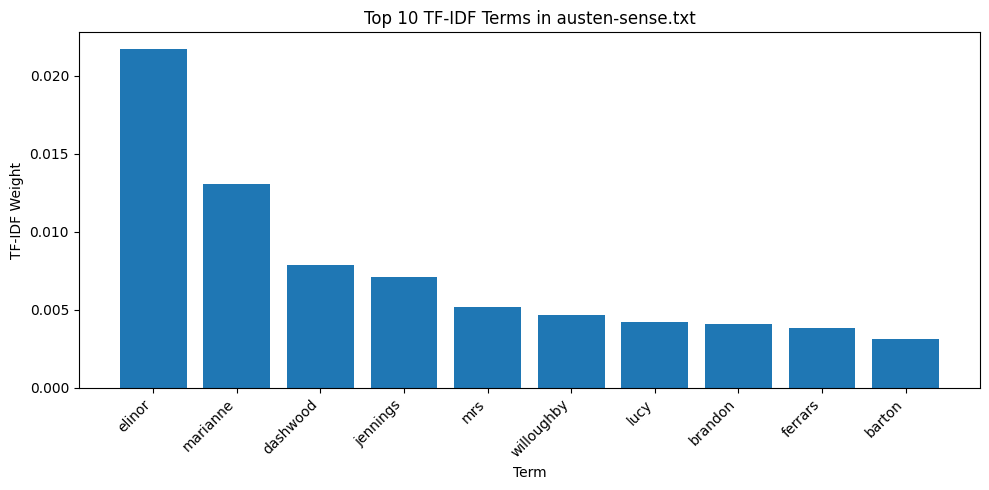

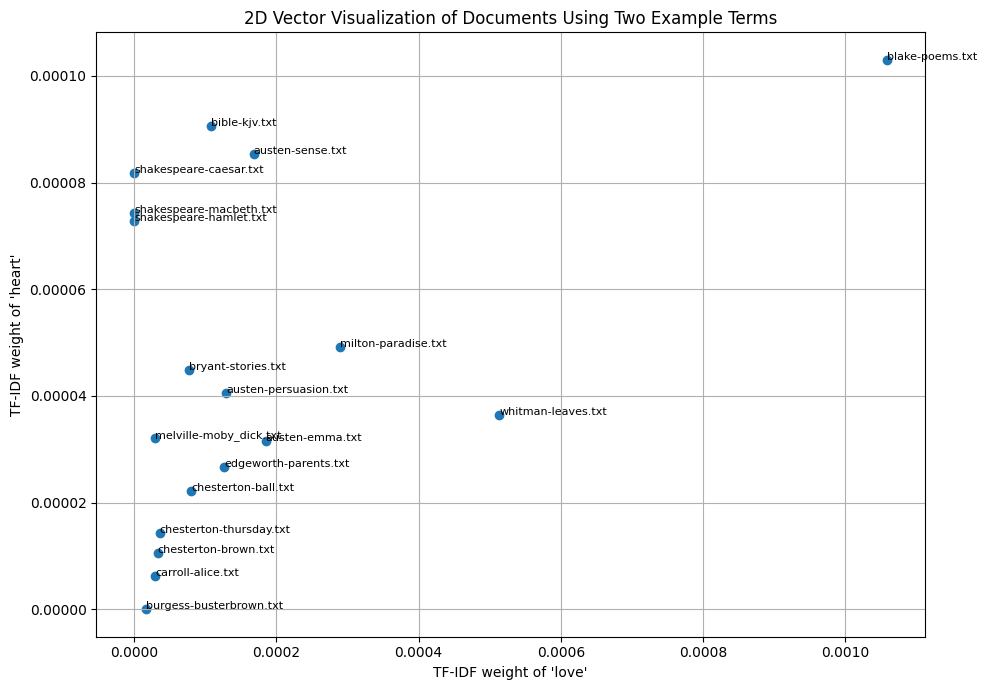

In [65]:
def plot_top_tfidf_terms(doc_id, top_n=10):
    term_weights = tf_idf[doc_id]
    top_terms = sorted(term_weights.items(), key=lambda x: x[1], reverse=True)[:top_n]

    terms = [t for t, w in top_terms]
    weights = [w for t, w in top_terms]

    plt.figure(figsize=(10, 5))
    plt.bar(terms, weights)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Top {top_n} TF-IDF Terms in {doc_id}")
    plt.xlabel("Term")
    plt.ylabel("TF-IDF Weight")
    plt.tight_layout()
    plt.show()

# Plot for 3 example documents
print("\nShowing TF-IDF bar charts for 3 example documents...")
for d in doc_ids[:3]:
    plot_top_tfidf_terms(d, top_n=10)

# ---------------------------
# 17. 2D VECTOR VISUALIZATION USING TWO EXAMPLE TERMS
# ---------------------------
example_term_x = "love"
example_term_y = "heart"

# If one of these terms is missing, pick alternatives automatically
if example_term_x not in vocab or example_term_y not in vocab:
    frequent_terms = [term for term, freq in df.items() if freq >= 3]
    example_term_x = frequent_terms[0]
    example_term_y = frequent_terms[1]

x_values = []
y_values = []
labels = []

for doc_id in doc_ids:
    x = tf_idf[doc_id].get(example_term_x, 0.0)
    y = tf_idf[doc_id].get(example_term_y, 0.0)
    x_values.append(x)
    y_values.append(y)
    labels.append(doc_id)

plt.figure(figsize=(10, 7))
plt.scatter(x_values, y_values)

for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), fontsize=8)

plt.xlabel(f"TF-IDF weight of '{example_term_x}'")
plt.ylabel(f"TF-IDF weight of '{example_term_y}'")
plt.title("2D Vector Visualization of Documents Using Two Example Terms")
plt.grid(True)
plt.tight_layout()
plt.show()


## 17. Visulaization of document similarities

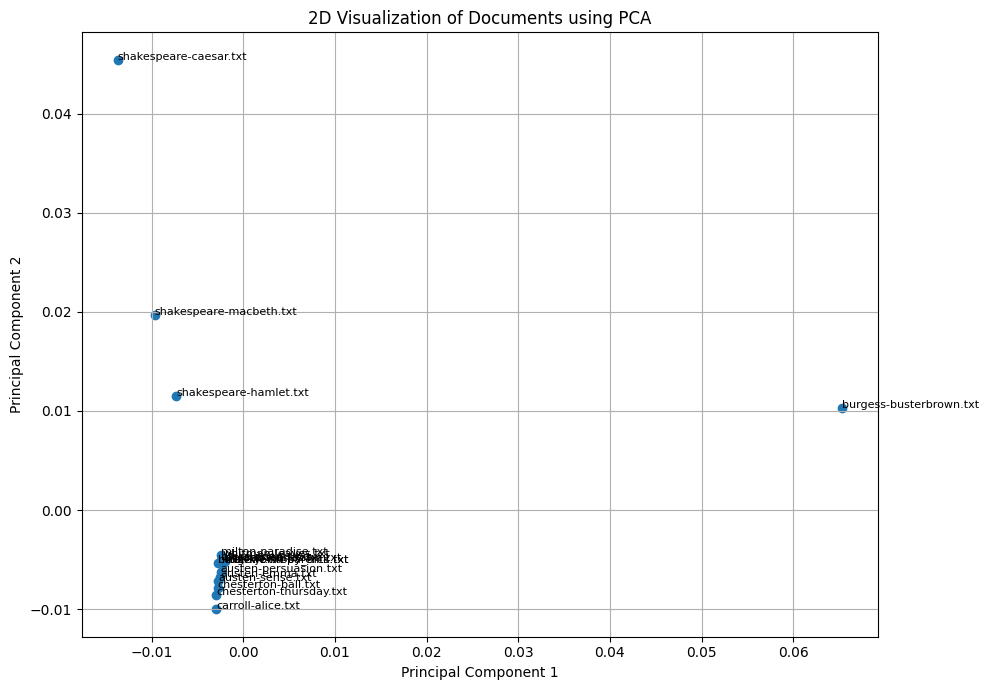

In [69]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

X = np.array([doc_vectors[d] for d in doc_ids])

pca = PCA(n_components=3)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1])

for i, doc_id in enumerate(doc_ids):
    plt.annotate(doc_id, (X_2d[i, 0], X_2d[i, 1]), fontsize=8)

plt.title("2D Visualization of Documents using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()